(genai_01_basic_tutorial)=
# Deploying an LLM using MLRun
This notebook illustrates deploying an LLM using MLRun.

Since this tutorial is for illustrative purposes, it uses minimal resources &mdash; CPU and not GPU, and a small amount of data.

**In this tutorial:**
- [MLRun installation and configuration](#mlrun-installation-and-configuration)
- [Set up the vector database in the cluster](#set-up-the-vector-database-in-the-cluster)
- [Build the vector DB](#build-the-vector-db)
- [Serving the function](#serving-the-function)

**See also:**
- [Model monitoring](https://docs.mlrun.org/en/stable/concepts/model-monitoring.html)
- [Alerts-notifications](https://docs.mlrun.org/en/stable/concepts/alerts-notifications.html)

<iframe width="560" height="315" src="https://www.youtube.com/embed/aoP__SaAO1M" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe><br><br>

## MLRun installation and configuration

Before running this notebook make sure the `mlrun` package is installed (`pip install mlrun`) and that you have configured the access to MLRun service. 

In [ ]:
# Install MLRun if not installed, run this only once. Restart the notebook after the install
%pip install mlrun

In [105]:
import json
import mlrun

**Get or create a new project**

First create, load or use (get) an [MLRun Project](https://docs.mlrun.org/en/stable/projects/project.html). The [get_or_create_project](https://docs.mlrun.org/en/stable/api/mlrun.projects/index.html#mlrun.projects.get_or_create_project method tries to load the project from the MLRun DB. If the project does not exist, it creates a new one.

In [106]:
project = mlrun.get_or_create_project("genai-tutorial", user_project=True)

> 2025-05-08 07:45:01,703 [info] Project loaded successfully: {"project_name":"genai-tutorial-edmond"}


## Set up the vector database in the cluster 
These two steps imports a pre-defined dataset and load it into a vector database. Then the vector database is stored in the data layer of the cluster.

If you're not using Iguazio's Jupyter, download {download}`fetch-vectordb-data.py <src/fetch-vectordb-data.py>`.


The image for this step can be created using the following Dockerfile (contains MLRun and Chroma DB):
```
FROM mlrun/mlrun
RUN pip install chromadb langchain langchain-community langchain-core langchain-text-splitters clean-text
```

In [107]:
# The model used is the free open-source PHI 2
MODEL_ID = "microsoft/phi-2"

# Define the dataset for the VectorDB
DATA_SET = mlrun.get_sample_path("data/genai-tutorial/labelled_newscatcher_dataset.csv")

# The location of the VectorDB files
CACHE_DIR = mlrun.mlconf.artifact_path
CACHE_DIR = (
    CACHE_DIR.replace("v3io://", "/v3io").replace("{{run.project}}", project.name)
    + "/cache"
)

Fetch the dataset for the Vector DB and save it in cluster:

In [108]:
fetch = project.set_function(
    name="fetch-vectordb-data",
    func="src/fetch-vectordb-data.py",
    kind="job",
    image="gcr.io/iguazio/mlrun-genai/llm-demo-data:1.8.0",
)

In [109]:
fetch.save()

'db://genai-tutorial-edmond/fetch-vectordb-data:latest'

In [110]:
ret = project.run_function(
    name="fetch-vectordb-data-run",
    function="fetch-vectordb-data",
    handler="handler",
    params={"data_set": DATA_SET},
)

> 2025-05-08 07:45:10,183 [info] Storing function: {"db":"http://mlrun-api:8080","name":"fetch-vectordb-data-run","uid":"7b7e0737a6cf41fe9402b13d854e535e"}
> 2025-05-08 07:45:10,588 [info] Job is running in the background, pod: fetch-vectordb-data-run-6hc9n
Since the GPL-licensed package `unidecode` is not installed, using Python's `unicodedata` package which yields worse results.
USER_AGENT environment variable not set, consider setting it to identify your requests.
See API reference for updated usage: https://python.langchain.com/api_reference/community/document_loaders/langchain_community.document_loaders.web_base.WebBaseLoader.html
Fetching pages:   8%|7         | 6/80 [00:02<00:29,  2.51it/s]Error fetching https://en.brinkwire.com/science/scientists-hope-to-clone-almost-extinct-sumatran-rhinoceros/ with attempt 2/3: Cannot connect to host en.brinkwire.com:443 ssl:default [Name or service not known]. Retrying...
Error fetching https://en.brinkwire.com/science/scientists-hope-to-clo

project,uid,iter,start,end,state,kind,name,labels,inputs,parameters,results,artifacts
genai-tutorial-edmond,...854e535e,0,May 08 07:45:19,2025-05-08 07:46:18.940215+00:00,completed,run,fetch-vectordb-data-run,v3io_user=edmondkind=jobowner=edmondmlrun/client_version=1.8.0-rc43mlrun/client_python_version=3.9.18host=fetch-vectordb-data-run-6hc9n,,data_set=https://s3.wasabisys.com/iguazio/data/genai-tutorial/labelled_newscatcher_dataset.csv,,vector-db-dataset


> 2025-05-08 07:46:22,259 [info] Run execution finished: {"name":"fetch-vectordb-data-run","status":"completed"}


In [18]:
ret.outputs

{'vector-db-dataset': 'store://datasets/genai-tutorial-edmond/fetch-vectordb-data-run_vector-db-dataset:latest@89ad21c7a7954c67b6164342fd388673^fe9e58b0585cff6c7ed18dee27e74f12d425cf05'}

## Build the vector DB

Build the vector DB in the data layer and load the data into it.

The image for this step can be created using the following Dockerfile (contains MLRun and Chroma DB):
```
FROM mlrun/mlrun
RUN pip install chromadb langchain langchain-community langchain-core langchain-text-splitters clean-text
```

If you're not using Iguazio's Jupyter, download {download}`the build vector db <./src/build-vector-db.py>`.

In [111]:
# Build the vector DB using the image
build_vectordb = project.set_function(
    name="build-vectordb",
    func="src/build-vector-db.py",
    kind="job",
    image="gcr.io/iguazio/mlrun-genai/llm-demo-data:1.8.0",
).apply(mlrun.auto_mount())

In [112]:
build_vectordb.save()

'db://genai-tutorial-edmond/build-vectordb:latest'

In [ ]:
project.run_function(
    function="build-vectordb",
    inputs={"df": ret.outputs["vector-db-dataset"]},
    params={"cache_dir": CACHE_DIR},
    handler="handler_chroma",
)

## Serving the function

The image for this step can be created using the following Dockerfile (contains Chroma DB, Transformers, TF and PyTorch):

```
FROM mlrun/mlrun
RUN pip install chromadb transformers tensorflow torch
```

If you're not using Iguazio's Jupyter, download {download}`serving.py <./src/serving.py>`.
Now you can deploy the the Nuclio function that serves the LLM:

In [116]:
serve_func = project.set_function(
    name="serve-llm",
    func="src/serving.py",
    image="gcr.io/iguazio/mlrun-genai/llmserve:1.0",
    kind="nuclio",
).apply(mlrun.auto_mount())

# Transferring the model and VectorDB path to the serving functions
serve_func.set_envs(env_vars={"MODEL_ID": MODEL_ID, "CACHE_DIR": CACHE_DIR})

# Since the model is stored in memory, use only 1 replica and and one worker
# Since this is running on CPU only, inference might take ~1 minute (increasing timeout)
serve_func.spec.min_replicas = 1
serve_func.spec.max_replicas = 1
serve_func.with_http(worker_timeout=120, gateway_timeout=150, workers=1)
serve_func.set_config("spec.readinessTimeoutSeconds", 1200)

> 2025-05-08 09:18:41,166 [warning] Adding HTTP trigger despite the default HTTP trigger creation being disabled


In [117]:
serve_func = project.deploy_function(function="serve-llm")

> 2025-05-08 09:18:43,166 [info] Starting remote function deploy
2025-05-08 09:18:43  (info) Deploying function
2025-05-08 09:18:43  (info) Building
2025-05-08 09:18:44  (info) Staging files and preparing base images
2025-05-08 09:18:44  (warn) Using user provided base image, runtime interpreter version is provided by the base image
2025-05-08 09:18:44  (info) Building processor image
2025-05-08 09:24:09  (info) Build complete
2025-05-08 09:24:54  (info) Function deploy complete
> 2025-05-08 09:24:57,972 [info] Successfully deployed function: {"external_invocation_urls":["genai-tutorial-edmond-serve-llm.default-tenant.app.cust-cs-il.iguazio-cd0.com/"],"internal_invocation_urls":["nuclio-genai-tutorial-edmond-serve-llm.default-tenant.svc.cluster.local:8080"]}


### Test Serving Function

In [118]:
body = {
    "question": "What are some new developments in space travel?",
    "topic": "science",
}

In [119]:
resp = serve_func.function.invoke("/", body=json.dumps(body))

> 2025-05-08 09:26:42,142 [info] Invoking function: {"method":"POST","path":"http://nuclio-genai-tutorial-edmond-serve-llm.default-tenant.svc.cluster.local:8080/"}


In [120]:
print(resp["response"])


Some new developments in space travel include the successful launch of a rocket from Earth, which poses a threat to space travel. Additionally, there have been advancements in the field of science, with new discoveries and breakthroughs being made. The news also covers topics such as politics, royal affairs, showbiz and TV, sports, finance, travel, life and style, comment, and world news.



In [121]:
print(resp["sources"])

['https://www.express.co.uk/news/science/1324095/space-news-spacex-rocket-launch-stars-elon-musk-Comet-Neowise-latest']


In [122]:
print(resp["prompt"])

The instruction below describes a task. Write a response that appropriately completes the request.

### Instruction:
User question:
What are some new developments in space travel?

Context:
Space news: Rocket launches from earth pose threat to space travel | Science | News | Express.co.uk Express. Home of the Daily and Sunday Express. Puzzles Horoscopes Express Rated Shop Paper Newsletters Login Register Your Account Newsletters Bookmarks Sign OutUkUs 10C Find us on FacebookFollow us on WhatsApp Follow us on TwitterFind us on Instagram Find us on Youtube Search HOME News Politics Royal Showbiz & TV Sport Finance Travel Life & Style Comment UK World Politics Royal US Weather Science

### Response:



In [104]:
project.set_function(f"db://{project.name}/fetch-vectordb-data")
project.set_function(f"db://{project.name}/build-vectordb")
project.set_function(f"db://{project.name}/serve-llm")
project.save()

### Run E2E Workflow

In [25]:
%%writefile workflow.py
import mlrun
from kfp import dsl

    
@dsl.pipeline(
    name="GenAI demo"
)

def kfpipeline(data_set, cache_dir):
    
    project = mlrun.get_current_project()
    
    fetch = project.run_function(
        function="fetch-vectordb-data",
        name="fetch-vectordb-data-run",
        handler="handler",
        params = {"data_set" : data_set},
        outputs=['vector-db-dataset']
    )
    
    
    vectordb_build = project.run_function(
        function="build-vectordb",
        inputs={"df" : fetch.outputs["vector-db-dataset"]},
        params={"cache_dir" : cache_dir},
        handler="handler_chroma"
    )

    deploy = project.deploy_function("serve-llm").after(vectordb_build)

Writing workflow.py


In [26]:
project.set_workflow("main", "workflow.py", embed=True)

In [27]:
project.save()

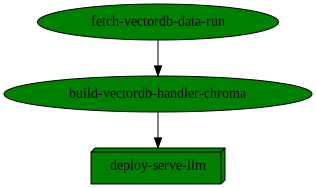

uid,start,state,name,parameters,results
...3abbfaf9,Jun 17 23:03:44,completed,build-vectordb-handler-chroma,cache_dir=/v3io/projects/genai-tutorial-new/artifacts/cache,
...a726980f,Jun 17 23:02:17,completed,fetch-vectordb-data-run,data_set=https://s3.wasabisys.com/iguazio/data/genai-tutorial/labelled_newscatcher_dataset.csv,


In [28]:
run_id = project.run(
    "main", arguments={"cache_dir": CACHE_DIR, "data_set": DATA_SET}, watch=True
)